In [1]:
'''AirPassengers dataset,which contains 
monthly totals of international airline passengers 
from 1949 to 1960.
The dataset is provided below.'''

'AirPassengers dataset,which contains \nmonthly totals of international airline passengers \nfrom 1949 to 1960.\nThe dataset is provided below.'

In [2]:
import pandas as pd
df=pd.read_csv("C:/Deep Learning/AirPassengers.csv")
print(df)

       Month  #Passengers
0    1949-01          112
1    1949-02          118
2    1949-03          132
3    1949-04          129
4    1949-05          121
..       ...          ...
139  1960-08          606
140  1960-09          508
141  1960-10          461
142  1960-11          390
143  1960-12          432

[144 rows x 2 columns]


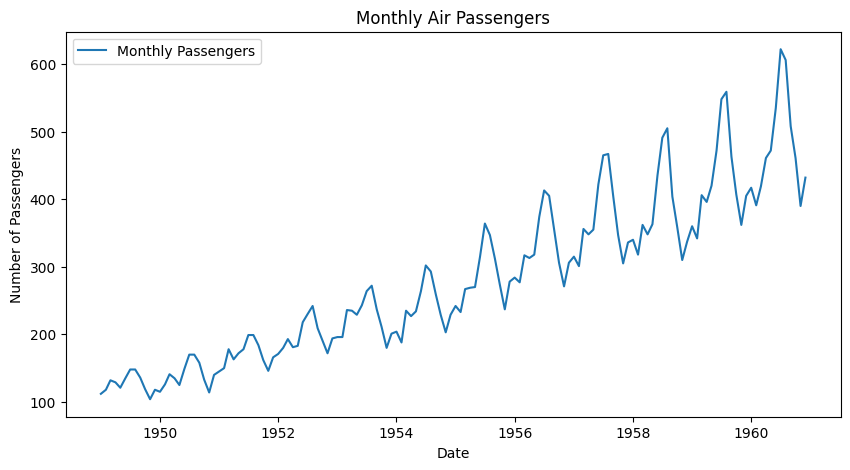

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Convert 'Month' to datetime and set as index
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(df['#Passengers'], label='Monthly Passengers')
plt.title('Monthly Air Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

In [4]:
from sklearn.preprocessing import MinMaxScaler

data = df['#Passengers'].values.reshape(-1, 1)

# Normalize the data to range [0, 1]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


In [5]:
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 12  # Use past 12 months to predict the next
X, y = create_sequences(scaled_data, seq_length)

# Reshape for LSTM: (samples, time steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=100, batch_size=8, verbose=1)


Epoch 1/100


c:\Users\Lenovo LOQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1023
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0165
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0089
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0120
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0111
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0097
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0108
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0083
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0084
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0107
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0079
Epoch 13/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0154
Epoch 14/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0106
Epoch 15/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0114
Epoch 16/100
17/

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


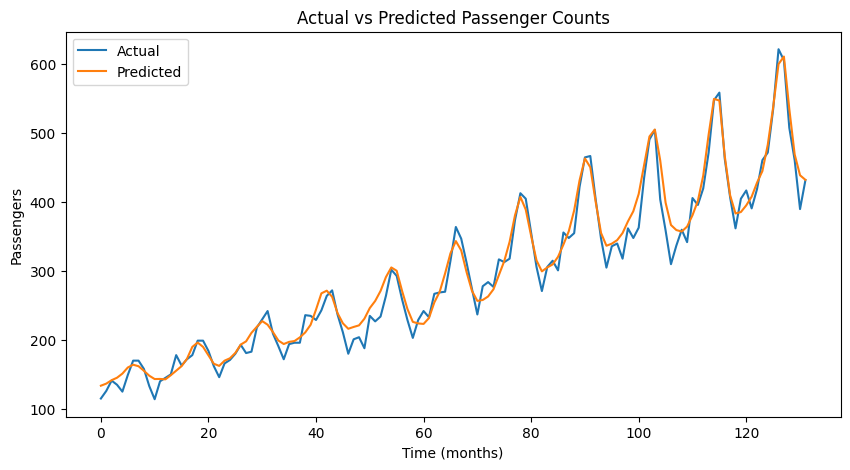

In [9]:
# Predict on training data just for visualization
predicted = model.predict(X)
predicted = scaler.inverse_transform(predicted)
y_actual = scaler.inverse_transform(y)

# Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.plot(y_actual, label='Actual')
plt.plot(predicted, label='Predicted')
plt.title('Actual vs Predicted Passenger Counts')
plt.xlabel('Time (months)')
plt.ylabel('Passengers')
plt.legend()
plt.show()
